In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from load_data import read_data, create_combined_dataset
from baseline_correct import baseline_roy, baseline_intermediates

In [3]:
path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG" ,
     "KG", "KG", "KG", "KG", "KG" ,"KG", "KG" ,"KG", "KG", "KG"],
          ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]
df = create_combined_dataset(path,normVP,infoP)

df['intensity_baseline_corrected'] = None
for idx, row in df.iterrows():
    df.at[idx, "intensity_baseline_corrected"] = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseline corrected!")

Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

In [5]:
print(df["infoP"].value_counts())
df.head()
df.info()

infoP
KG    19
PC    17
M     15
H      8
F      7
BC     5
KC     3
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    74 non-null     object
 1   original_filename             74 non-null     object
 2   category                      74 non-null     object
 3   normVP                        74 non-null     int64 
 4   infoP                         74 non-null     object
 5   wavenumber                    74 non-null     object
 6   intensity                     74 non-null     object
 7   spectrum_length               74 non-null     int64 
 8   intensity_baseline_corrected  74 non-null     object
dtypes: int64(2), object(7)
memory usage: 5.3+ KB


In [6]:
SRs = {
    # "SR_1005": (990, 1020),
    "SR_1190": (1175, 1195),
    # "SR_1190": (1175, 1205),
    "SR_1203": (1188, 1218),
    "SR_530": (515, 545),
    "SR_2170" : (2157, 2193)
}


In [7]:
def extract_sr_matrix(df, start, end):
    # Find indices once for the first row
    wn = df.iloc[0]['wavenumber']
    mask = (wn >= start) & (wn <= end)
    return np.stack(df['intensity'].apply(lambda x: x[mask]).values)

SR_matrices = {}
for name, (s,e) in SRs.items():
    SR_matrices[name] = extract_sr_matrix(df, s, e)


In [8]:
print("(rows = patients, cols = spectral points)")
for k in SR_matrices.keys():
    print(f"shape of matrix corresponding to {k} : {SR_matrices[k].shape}")


(rows = patients, cols = spectral points)
shape of matrix corresponding to SR_1190 : (74, 83)
shape of matrix corresponding to SR_1203 : (74, 124)
shape of matrix corresponding to SR_530 : (74, 124)
shape of matrix corresponding to SR_2170 : (74, 150)


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


pca_results = {}
for name, mat in SR_matrices.items():
    print("before standard scaler")
    print("Feature means:", mat.mean(axis=0)[:5])
    print("Feature stds:", mat.std(axis=0)[:5])

# 3. Apply proper scaling BEFORE PCA

    scaler = StandardScaler()
    mat = scaler.fit_transform(mat)  # Mean=0, Std=1 per feature
    print("after standard scaler")
    print("Feature means:", mat.mean(axis=0)[:5])
    print("Feature stds:", mat.std(axis=0)[:5])
    numPcs = 4
    pca = PCA(n_components=numPcs)   # same as paper up to PC4
    pcs = pca.fit_transform(mat)
    pca_results[name] = pcs



before standard scaler
Feature means: [-0.01405905 -0.014045   -0.01404365 -0.01404216 -0.01404176]
Feature stds: [0.00468804 0.00467303 0.00466015 0.00465609 0.00466193]
after standard scaler
Feature means: [-6.61632911e-16 -1.86037372e-16 -2.04040988e-16  1.32026522e-16
  7.06641952e-16]
Feature stds: [1. 1. 1. 1. 1.]
before standard scaler
Feature means: [-0.01380135 -0.01379784 -0.01378189 -0.01376297 -0.01376135]
Feature stds: [0.00456672 0.00456564 0.00457659 0.00458151 0.00456442]
after standard scaler
Feature means: [ 1.03295750e-15  3.75075346e-17 -1.54531043e-16  1.20849277e-15
 -5.73865280e-16]
Feature stds: [1. 1. 1. 1. 1.]
before standard scaler
Feature means: [-0.03422054 -0.03411473 -0.03408554 -0.03413486 -0.034095  ]
Feature stds: [0.0165402  0.01642607 0.01642137 0.01645674 0.01638479]
after standard scaler
Feature means: [-3.28566003e-16 -6.94639541e-16  5.47610005e-16 -5.65613622e-16
 -1.80036166e-17]
Feature stds: [1. 1. 1. 1. 1.]
before standard scaler
Feature mea

In [ ]:
result_df = df[['patient_id','infoP']].copy()
for name, pcs in pca_results.items():
    for n in range(numPcs):
        result_df[f'{name}_PC{n+1}'] = pcs[:,n]
    # result_df[f'{name}_PC2'] = pcs[:,1]
    # result_df[f'{name}_PC3'] = pcs[:,2]
    # result_df[f'{name}_PC4'] = pcs[:,3]
    # result_df[f'{name}_PC5'] = pcs[:,4]
result_df = result_df[result_df['infoP'].isin(["PC", "M", "F", "H"])]
result_df["class"] = result_df["infoP"].apply(lambda x: "Cancer" if x == 'PC' else "Healthy")





In [24]:
result_df.info()
print(result_df["class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 73
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   47 non-null     object 
 1   infoP        47 non-null     object 
 2   SR_1190_PC1  47 non-null     float64
 3   SR_1190_PC2  47 non-null     float64
 4   SR_1190_PC3  47 non-null     float64
 5   SR_1190_PC4  47 non-null     float64
 6   SR_1203_PC1  47 non-null     float64
 7   SR_1203_PC2  47 non-null     float64
 8   SR_1203_PC3  47 non-null     float64
 9   SR_1203_PC4  47 non-null     float64
 10  SR_530_PC1   47 non-null     float64
 11  SR_530_PC2   47 non-null     float64
 12  SR_530_PC3   47 non-null     float64
 13  SR_530_PC4   47 non-null     float64
 14  SR_2170_PC1  47 non-null     float64
 15  SR_2170_PC2  47 non-null     float64
 16  SR_2170_PC3  47 non-null     float64
 17  SR_2170_PC4  47 non-null     float64
 18  class        47 non-null     object 
dtypes: float64(16),

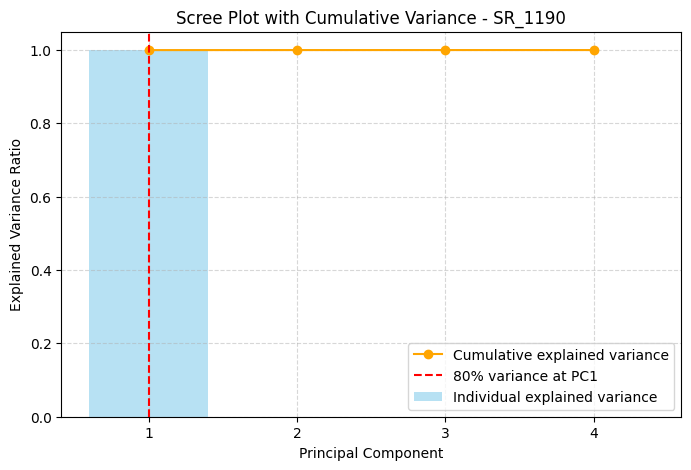

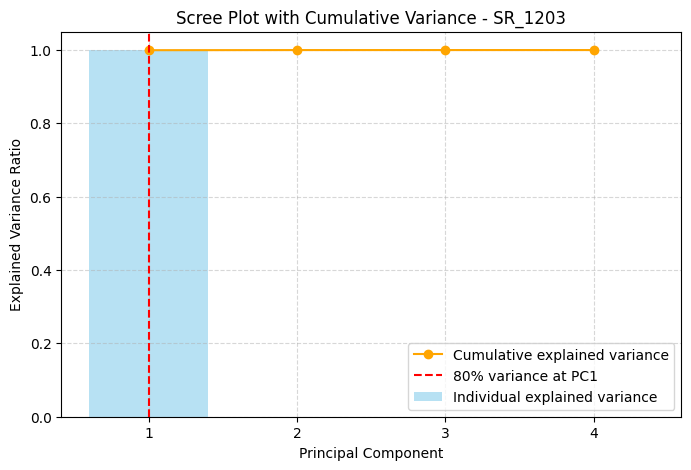

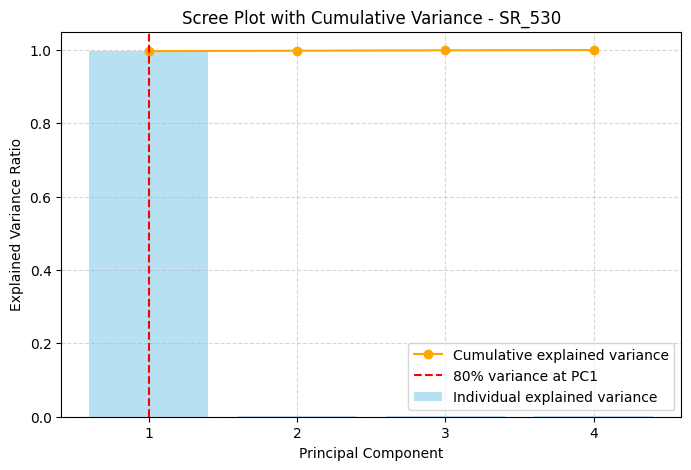

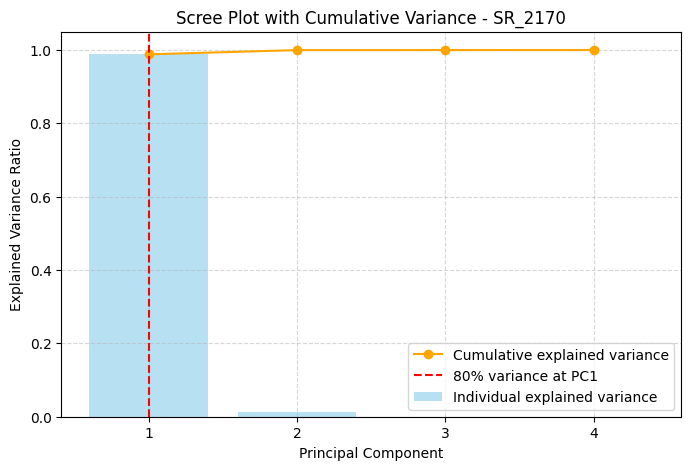

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Example: assuming pca is a fitted PCA object from sklearn
# If you have multiple PCA results, loop over them
for name, pcs in pca_results.items():
    
    # If you have the actual PCA object, use explained_variance_ratio_
    if hasattr(pcs, 'explained_variance_ratio_'):
        evr = pcs.explained_variance_ratio_
    else:
        # Compute variance explained manually if you only have transformed data
        evr = pcs.var(axis=0) / pcs.var(axis=0).sum()
    evr = np.sort(evr)[::-1]  # Sort explained variance in descending order

    cum_evr = np.cumsum(evr)

    plt.figure(figsize=(8,5))
    
    # Bar plot: individual variance explained
    plt.bar(range(1, len(evr)+1), evr, alpha=0.6, color='skyblue', label='Individual explained variance')
    
    # Line plot: cumulative variance explained
    plt.plot(range(1, len(evr)+1), cum_evr, marker='o', color='orange', label='Cumulative explained variance')
    
    # Annotate where cumulative variance exceeds 80%
    for i, cumulative in enumerate(cum_evr):
        if cumulative >= 0.8:
            plt.axvline(x=i+1, color='red', linestyle='--', label=f'80% variance at PC{i+1}')
            break
    
    plt.title(f"Scree Plot with Cumulative Variance - {name}")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.xticks(range(1, len(evr)+1))
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


In [13]:
# result_df = result_df.query("infoP in ['BC', 'KC', 'PC', 'H']")
# result_df.info()
print(result_df.info())
result_df["infoP"].value_counts()


<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 73
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   47 non-null     object 
 1   infoP        47 non-null     object 
 2   SR_1190_PC1  47 non-null     float64
 3   SR_1190_PC2  47 non-null     float64
 4   SR_1190_PC3  47 non-null     float64
 5   SR_1190_PC4  47 non-null     float64
 6   SR_1203_PC1  47 non-null     float64
 7   SR_1203_PC2  47 non-null     float64
 8   SR_1203_PC3  47 non-null     float64
 9   SR_1203_PC4  47 non-null     float64
 10  SR_530_PC1   47 non-null     float64
 11  SR_530_PC2   47 non-null     float64
 12  SR_530_PC3   47 non-null     float64
 13  SR_530_PC4   47 non-null     float64
 14  SR_2170_PC1  47 non-null     float64
 15  SR_2170_PC2  47 non-null     float64
 16  SR_2170_PC3  47 non-null     float64
 17  SR_2170_PC4  47 non-null     float64
 18  class        47 non-null     object 
dtypes: float64(16),

infoP
PC    17
M     15
H      8
F      7
Name: count, dtype: int64

In [14]:
# Check the exact column names first
print("Columns:", result_df.columns.tolist())

# Then use the correct column name
# result_df = result_df[result_df['infoP  '].isin(['PC', "H"])]

Columns: ['patient_id', 'infoP', 'SR_1190_PC1', 'SR_1190_PC2', 'SR_1190_PC3', 'SR_1190_PC4', 'SR_1203_PC1', 'SR_1203_PC2', 'SR_1203_PC3', 'SR_1203_PC4', 'SR_530_PC1', 'SR_530_PC2', 'SR_530_PC3', 'SR_530_PC4', 'SR_2170_PC1', 'SR_2170_PC2', 'SR_2170_PC3', 'SR_2170_PC4', 'class']


In [15]:
result_df.info()
# pvalue_df

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 73
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   47 non-null     object 
 1   infoP        47 non-null     object 
 2   SR_1190_PC1  47 non-null     float64
 3   SR_1190_PC2  47 non-null     float64
 4   SR_1190_PC3  47 non-null     float64
 5   SR_1190_PC4  47 non-null     float64
 6   SR_1203_PC1  47 non-null     float64
 7   SR_1203_PC2  47 non-null     float64
 8   SR_1203_PC3  47 non-null     float64
 9   SR_1203_PC4  47 non-null     float64
 10  SR_530_PC1   47 non-null     float64
 11  SR_530_PC2   47 non-null     float64
 12  SR_530_PC3   47 non-null     float64
 13  SR_530_PC4   47 non-null     float64
 14  SR_2170_PC1  47 non-null     float64
 15  SR_2170_PC2  47 non-null     float64
 16  SR_2170_PC3  47 non-null     float64
 17  SR_2170_PC4  47 non-null     float64
 18  class        47 non-null     object 
dtypes: float64(16),

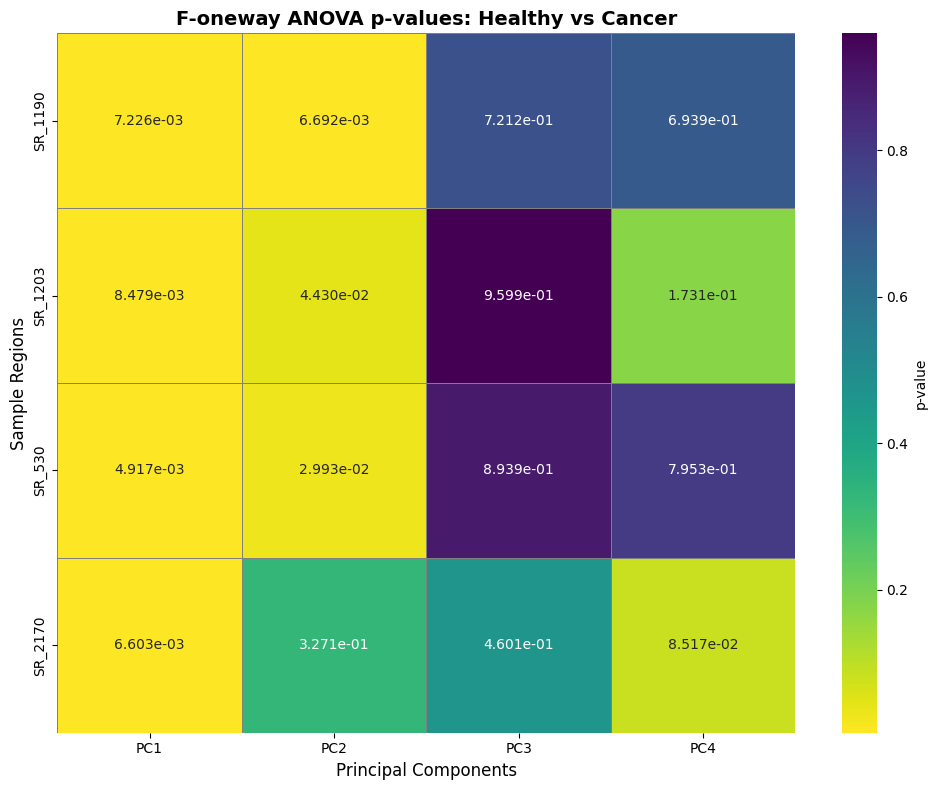

In [16]:
from scipy.stats import f_oneway
import seaborn as sns

pvalue_matrix = []
for name in SRs.keys():
    row = []
    for pc in [f"PC{n+1}" for n in range(numPcs)]:
        h = result_df[result_df['class']=='Healthy'][f'{name}_{pc}']
        c = result_df[result_df['class']=='Cancer'][f'{name}_{pc}']
        # print(name, pc, f_oneway(h,c).pvalue)
        pval = f_oneway(h, c).pvalue
        row.append(pval)
    pvalue_matrix.append(row)

# Convert to DataFrame for better visualization
pvalue_df = pd.DataFrame(
    pvalue_matrix,
    index=list(SRs.keys()),  # Row names
    columns=[f"PC{n+1}" for n in range(numPcs)]  # Column names
)


# Create the heatmap
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    pvalue_df,
    annot=True,           # Show p-values on cells
    fmt=".3e",           # Scientific notation for small p-values
    cmap='viridis_r',    # Reverse viridis (darker = smaller p-value)
    cbar_kws={'label': 'p-value'},
    linewidths=0.5,
    linecolor='gray'
)

plt.title('F-oneway ANOVA p-values: Healthy vs Cancer', fontsize=14, fontweight='bold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Sample Regions', fontsize=12)
plt.tight_layout()
plt.show()





In [17]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV


y = LabelEncoder().fit_transform(result_df["class"])
SRl = [530, 1190, 2170, 1203]
# Separate SR regions
for SR in SRl:
   print(f"--------------------SR{SR}------------------------")
   sr = result_df[[c for c in result_df.columns if f"SR_{SR}" in c]]
   svm = SVC(kernel="linear")
   acc = cross_val_score(svm, sr, y, cv=9).mean()
   print(f"Accuracy SR_{SR}:", acc)

   X = result_df[[f"SR_{SR}_PC{n+1}" for n in range(numPcs)]].values
   y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values

    # ---- 9-fold CV ----
   kf9 = KFold(n_splits=9, shuffle=True, random_state=42)
   clf = SVC(kernel="linear")

   scores_9fold = cross_val_score(clf, X, y, cv=kf9)

#    print("9-fold accuracies:", scores_9fold)
   print("Mean 9-fold accuracy:", np.mean(scores_9fold))

   loo = LeaveOneOut()
   scores_loo = cross_val_score(clf, X, y, cv=loo)

#    print("LOOCV accuracies:", scores_loo)
   print("Mean LOOCV accuracy:", np.mean(scores_loo))


--------------------SR530------------------------
Accuracy SR_530: 0.6222222222222222
Mean 9-fold accuracy: 0.5518518518518518


/tmp/ipykernel_7055/517638418.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values
/tmp/ipykernel_7055/517638418.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values


Mean LOOCV accuracy: 0.5531914893617021
--------------------SR1190------------------------
Accuracy SR_1190: 0.5333333333333332
Mean 9-fold accuracy: 0.4666666666666667
Mean LOOCV accuracy: 0.6382978723404256
--------------------SR2170------------------------
Accuracy SR_2170: 0.6148148148148148
Mean 9-fold accuracy: 0.5925925925925927
Mean LOOCV accuracy: 0.6170212765957447
--------------------SR1203------------------------


/tmp/ipykernel_7055/517638418.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values
/tmp/ipykernel_7055/517638418.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values


Accuracy SR_1203: 0.5888888888888888
Mean 9-fold accuracy: 0.5518518518518518
Mean LOOCV accuracy: 0.6170212765957447


In [18]:
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut

cv_values = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

results = {}

for cv in cv_values:
    grid = GridSearchCV(
        SVC(),
        {'C':[0.1,1,10,100], 'gamma':['scale',0.1,0.01], 'kernel':['rbf']},
        cv=cv
    )
    grid.fit(X, y)
    results[f'cv={cv}'] = grid.best_score_

# LOOCV
loo = LeaveOneOut()
grid_loo = GridSearchCV(
    SVC(),
    {'C':[0.1,1,10,100,1000], 'gamma':['scale',0.1,0.01,0.001], 'kernel':['rbf']},
    cv=loo
)
grid_loo.fit(X, y)
results['LOOCV'] = grid_loo.best_score_
# print("Best parameters:", grid.best_params_) 
# print("Best accuracy:", grid.best_score_)

# print(results)

best_cv_name, best_cv_score = max(results.items(), key=lambda x: x[1])

print("Best parameters:", grid.best_params_)
print("Best grid-search accuracy:", grid.best_score_)
print(f"Best overall CV result: {best_cv_name} = {best_cv_score}")
# -----------------------

print(results)


Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best grid-search accuracy: 0.6777777777777777
Best overall CV result: cv=5 = 0.7044444444444443
{'cv=2': np.float64(0.6385869565217391), 'cv=3': np.float64(0.6388888888888888), 'cv=4': np.float64(0.6382575757575757), 'cv=5': np.float64(0.7044444444444443), 'cv=6': np.float64(0.6398809523809524), 'cv=7': np.float64(0.6394557823129251), 'cv=8': np.float64(0.6375), 'cv=9': np.float64(0.637037037037037), 'cv=10': np.float64(0.6849999999999999), 'cv=11': np.float64(0.6409090909090909), 'cv=12': np.float64(0.6805555555555555), 'cv=13': np.float64(0.6666666666666666), 'cv=14': np.float64(0.6428571428571429), 'cv=15': np.float64(0.6777777777777777), 'LOOCV': np.float64(0.7021276595744681)}


In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features (example: your SR_1190 PCs)
SR=1190
X = result_df[[f"SR_{SR}_PC{n+1}" for n in range(numPcs)]].values
y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values

# scale
X = StandardScaler().fit_transform(X)

# ---- 9-fold CV ----
kf9 = KFold(n_splits=9, shuffle=True, random_state=42)
clf = SVC(kernel="linear")

scores_9fold = cross_val_score(clf, X, y, cv=kf9)

print("9-fold accuracies:", scores_9fold)
print("Mean 9-fold accuracy:", np.mean(scores_9fold))

from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

scores_loo = cross_val_score(clf, X, y, cv=loo)

print("LOOCV accuracies:", scores_loo)
print("Mean LOOCV accuracy:", np.mean(scores_loo))

# from sklearn.model_selection import GridSearchCV

cv_values = [5,6,7,8,9,10,11]

results = {}

for cv in cv_values:
    grid = GridSearchCV(
        SVC(),
        {'C':[0.1,1,10,100], 'gamma':['scale',0.1,0.01], 'kernel':['rbf']},
        cv=cv
    )
    grid.fit(X, y)
    results[f'cv={cv}'] = grid.best_score_

# LOOCV
loo = LeaveOneOut()
grid_loo = GridSearchCV(
    SVC(),
    {'C':[0.1,1,10,100], 'gamma':['scale',0.1,0.01], 'kernel':['rbf']},
    cv=loo
)
grid_loo.fit(X, y)
results['LOOCV'] = grid_loo.best_score_
print("Best parameters:", grid.best_params_) 
print("Best accuracy:", grid.best_score_)
print(results)



9-fold accuracies: [0.5        0.66666667 0.2        0.4        0.8        0.4
 0.6        0.8        0.4       ]
Mean 9-fold accuracy: 0.5296296296296297
LOOCV accuracies: [0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.]
Mean LOOCV accuracy: 0.5319148936170213


/tmp/ipykernel_7055/3530171085.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values


Best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best accuracy: 0.7227272727272728
{'cv=5': np.float64(0.6577777777777778), 'cv=6': np.float64(0.7261904761904762), 'cv=7': np.float64(0.7482993197278912), 'cv=8': np.float64(0.7041666666666666), 'cv=9': np.float64(0.7444444444444444), 'cv=10': np.float64(0.725), 'cv=11': np.float64(0.7227272727272728), 'LOOCV': np.float64(0.723404255319149)}


/tmp/ipykernel_7055/631779334.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values


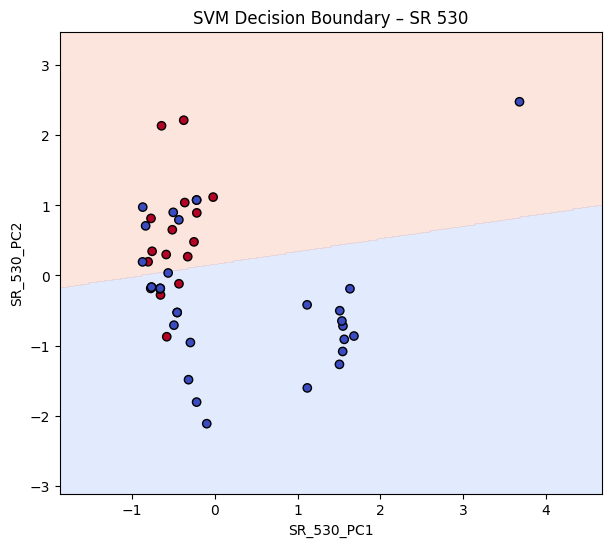

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --------- Prepare data ----------
# Suppose your DF looks like:
# ['SR_530_PC1','SR_530_PC2','SR_530_PC3','SR_530_PC4','class']

X = result_df[['SR_1190_PC1','SR_1190_PC2']].values   # for 2D plot
# X = result_df[['SR_530_PC1','SR_530_PC3']].values   # for 2D plot
y = result_df['class'].replace({'Healthy':0,'Cancer':1}).values

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --------- Fit simple SVM ----------
clf = SVC(kernel="linear")     # or "rbf"
clf.fit(X_train, y_train)

# --------- Make grid for decision visualization ----------
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --------- Plot ----------
plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.25, levels=[-1,0,1], cmap="coolwarm")
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap="coolwarm", edgecolor='k')
plt.title("SVM Decision Boundary – SR 530")
plt.xlabel("SR_530_PC1")
plt.ylabel("SR_530_PC2")
plt.show()


/tmp/ipykernel_7055/3438732227.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df['class'].replace({'Healthy':0, 'Cancer':1}).values


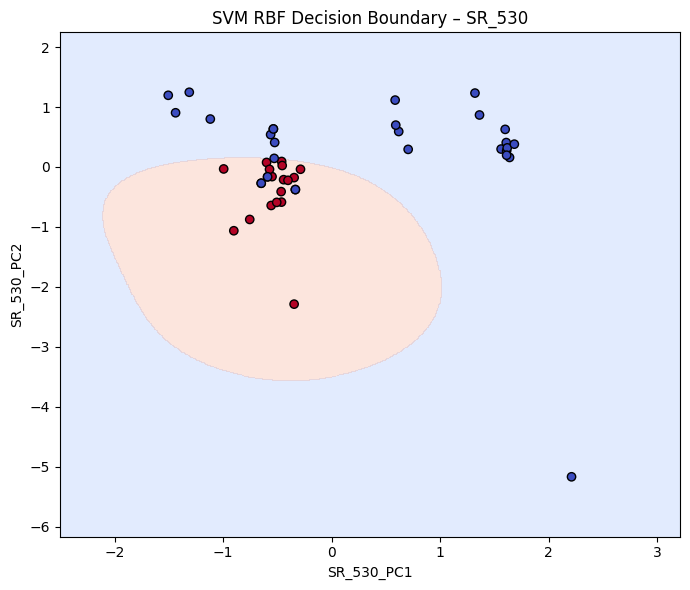

/tmp/ipykernel_7055/3438732227.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df['class'].replace({'Healthy':0, 'Cancer':1}).values


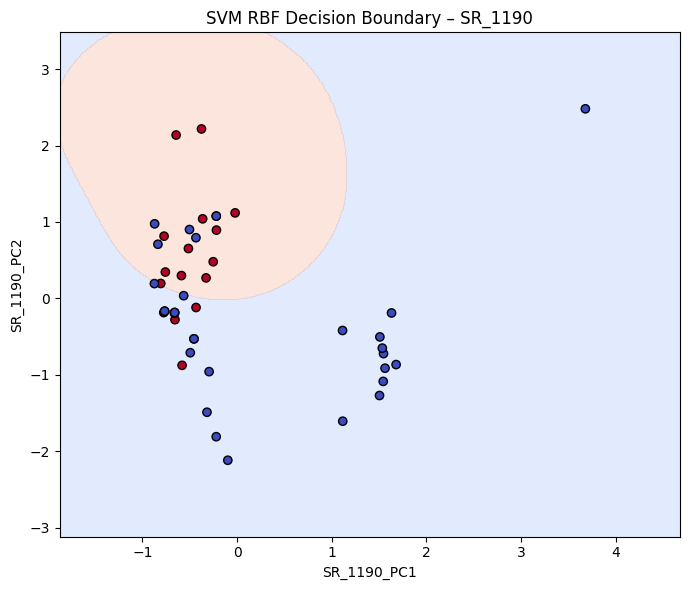

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

def plot_svm_region(df, region_name):
    """
    region_name: 'SR_530' or 'SR_1190'
    Uses PC1 and PC2 for 2D visualization
    """
    # Collect PC1 and PC2 from selected spectral region
    X = df[[f'{region_name}_PC1', f'{region_name}_PC2']].values
    y = df['class'].replace({'Healthy':0, 'Cancer':1}).values

    # Scale
    sc = StandardScaler()
    Xs = sc.fit_transform(X)

    # RBF SVM model with the best parameters you found
    clf = SVC(kernel='rbf', C=1, gamma='scale')
    clf.fit(Xs, y)

    # Create meshgrid
    x_min, x_max = Xs[:,0].min() - 1, Xs[:,0].max() + 1
    y_min, y_max = Xs[:,1].min() - 1, Xs[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm", levels=[-1,0,1])
    plt.scatter(Xs[:,0], Xs[:,1], c=y, edgecolor='k', cmap="coolwarm")
    plt.title(f"SVM RBF Decision Boundary – {region_name}")
    plt.xlabel(f"{region_name}_PC1")
    plt.ylabel(f"{region_name}_PC2")
    plt.tight_layout()
    plt.show()


# --------- Run for both regions ---------
plot_svm_region(result_df, "SR_530")
plot_svm_region(result_df, "SR_1190")
